In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pickle

In [15]:
data = pd.read_csv('/content/drive/MyDrive/Galton_Family_Heights.csv')
data.head()

,Father_height,Mother_height,Child_height,gender
0,78.5,67.0,73.2,1
1,78.5,67.0,69.2,0
2,78.5,67.0,69.0,0
3,78.5,67.0,69.0,0
4,75.5,66.5,73.5,1


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Father_height  934 non-null    float64
 1   Mother_height  934 non-null    float64
 2   Child_height   934 non-null    float64
 3   gender         934 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 29.3 KB


In [17]:
data.describe

<bound method NDFrame.describe of      Father_height  Mother_height  Child_height  gender
0             78.5           67.0          73.2       1
1             78.5           67.0          69.2       0
2             78.5           67.0          69.0       0
3             78.5           67.0          69.0       0
4             75.5           66.5          73.5       1
..             ...            ...           ...     ...
929           62.0           66.0          64.0       1
930           62.0           66.0          62.0       0
931           62.0           66.0          61.0       0
932           62.5           63.0          66.5       1
933           62.5           63.0          57.0       0

[934 rows x 4 columns]>

Multiple regression with different train-test splits and random states

In [18]:
X = data[["Father_height", "Mother_height", "gender"]]
y = data["Child_height"]

In [19]:
results = []
random_states = [0, 42, 100]
train_sizes = [0.8, 0.7]

In [20]:
for train_size in train_sizes:
    for random_state in random_states:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=1 - train_size, random_state=random_state
        )
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results.append((train_size, random_state, mse, r2))

In [21]:
results_df = pd.DataFrame(
    results, columns=["Train_Size", "Random_State", "MSE", "R2_Score"]
)

Subset Regression

In [22]:
subset_X = data[["Father_height", "Mother_height"]]  # Excluding 'gender'
subset_results = []

In [23]:
for train_size in train_sizes:
    for random_state in random_states:
        X_train, X_test, y_train, y_test = train_test_split(
            subset_X, y, test_size=1 - train_size, random_state=random_state
        )
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        subset_results.append((train_size, random_state, mse, r2))

In [24]:
subset_results_df = pd.DataFrame(
    subset_results, columns=["Train_Size", "Random_State", "MSE", "R2_Score"]
)

Polynomial regression with one predictor at a time

In [25]:
predictors = ["Father_height", "Mother_height"]
polynomial_results = []
degrees = [1, 2, 3]


In [26]:
for predictor in predictors:
    for degree in degrees:
        poly = PolynomialFeatures(degree=degree)
        X_poly = poly.fit_transform(data[[predictor]])
        X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        polynomial_results.append((predictor, degree, mse, r2))

polynomial_results_df = pd.DataFrame(
    polynomial_results, columns=["Predictor", "Degree", "MSE", "R2_Score"]
)


In [27]:
best_model_info = results_df.loc[results_df["R2_Score"].idxmax()]
best_random_state = int(best_model_info["Random_State"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1 - best_model_info["Train_Size"], random_state=best_random_state
)
final_model = LinearRegression()
final_model.fit(X_train, y_train)

with open("final_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

In [30]:
from google.colab import files
files.download('final_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Visualize polynomial regression results

In [28]:
results_df.to_csv("multiple_regression_results.csv", index=False)
subset_results_df.to_csv("subset_regression_results.csv", index=False)
polynomial_results_df.to_csv("polynomial_regression_results.csv", index=False)

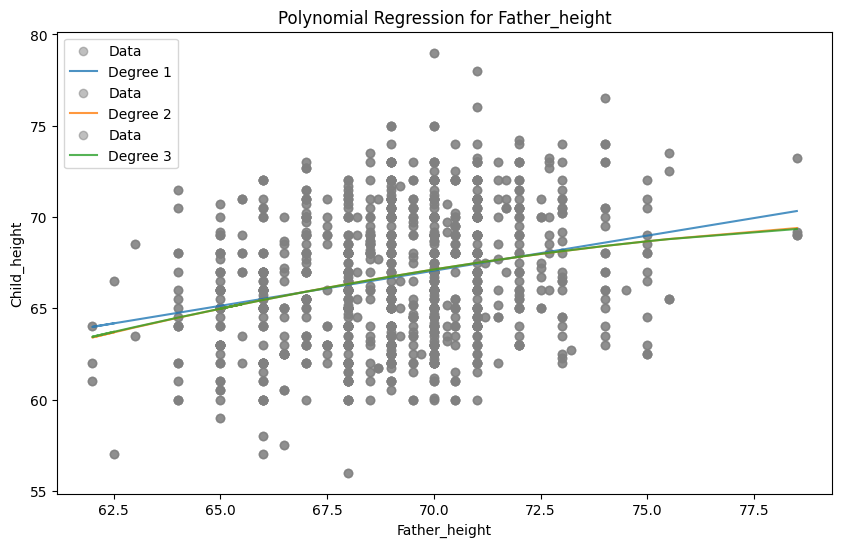

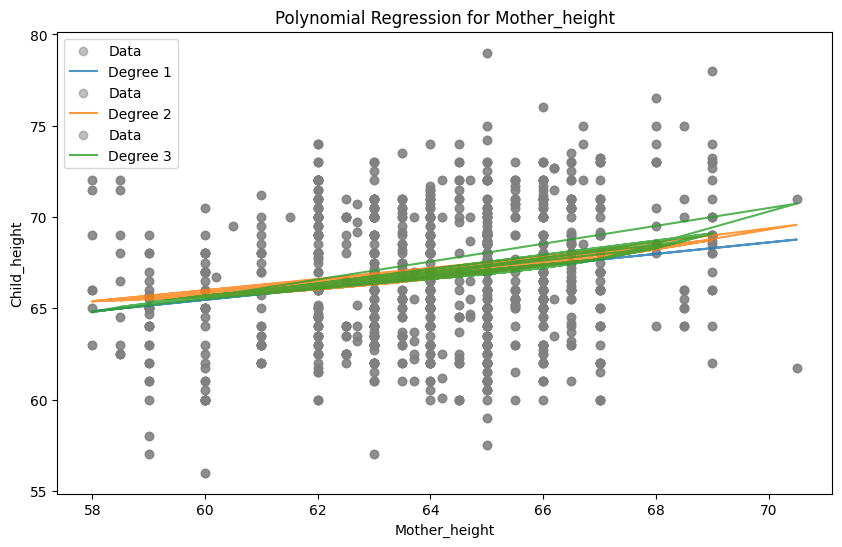

In [29]:
for predictor in predictors:
    plt.figure(figsize=(10, 6))
    for degree in degrees:
        poly = PolynomialFeatures(degree=degree)
        X_poly = poly.fit_transform(data[[predictor]])
        model = LinearRegression().fit(X_poly, y)
        y_pred = model.predict(X_poly)

        plt.scatter(data[predictor], y, color="gray", alpha=0.5, label="Data")
        plt.plot(
            data[predictor], y_pred, label=f"Degree {degree}", alpha=0.8
        )

    plt.title(f"Polynomial Regression for {predictor}")
    plt.xlabel(predictor)
    plt.ylabel("Child_height")
    plt.legend()
    plt.show()